This note is the workflow in action: **write in Jupyter, render with Quarto, publish to the site**.

At build time, Python cells download Parquet from the private R2 bucket (via the read-only Worker proxy), run DuckDB locally, and embed the charts in the HTML you are reading.

Data path: SEC EDGAR ABS-EE → `bens-data-lake` → R2 → this notebook. See [Data Sources](../../data-sources.qmd) for field definitions.

In [1]:
import os
import tempfile
import urllib.request
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

R2_BASE = os.environ.get(
    "R2_BASE_URL",
    "https://bens-field-notes-r2.benuehlinger-dev.workers.dev",
).rstrip("/")
UA = {"User-Agent": "bens-field-notes-notebook/1.0"}
CACHE = Path(tempfile.mkdtemp(prefix="abs-ee-notebook-"))


def fetch_r2(key: str, dest: Path) -> Path:
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.stat().st_size > 0:
        return dest
    req = urllib.request.Request(f"{R2_BASE}/{key}", headers=UA)
    with urllib.request.urlopen(req, timeout=180) as resp, open(dest, "wb") as out:
        out.write(resp.read())
    return dest


def fetch_catalog(yyyymm: str) -> pd.DataFrame | None:
    key = f"abs_ee/curated/catalog/{yyyymm}_autoloan.parquet"
    dest = CACHE / f"catalog_{yyyymm}.parquet"
    try:
        fetch_r2(key, dest)
    except Exception as exc:
        print(f"skip {yyyymm}: {exc}")
        return None
    return duckdb.connect().execute(
        f"SELECT * FROM read_parquet('{dest}') WHERE status = 'ok'"
    ).fetchdf()


print(f"R2 base: {R2_BASE}")
print(f"Cache:   {CACHE}")

R2 base: https://bens-field-notes-r2.benuehlinger-dev.workers.dev
Cache:   /var/folders/nj/dk45cxnd7v7crpyf_79q_x540000gn/T/abs-ee-notebook-hl4xjgt1


## Filing volume over time

Monthly **ingest catalogs** (`abs_ee/curated/catalog/{YYYYMM}_autoloan.parquet`) list every trust that filed in a given ingest month. Summing `loan_count` is a quick read on how much securitized auto paper is in the panel — not delinquency, but coverage.

In [2]:
# Representative ingest months (skip gracefully if a month is missing)
CATALOG_MONTHS = [
    "201805", "201905", "202005", "202105", "202205",
    "202305", "202405", "202505",
]

catalog_rows = []
for yyyymm in CATALOG_MONTHS:
    df = fetch_catalog(yyyymm)
    if df is None or df.empty:
        continue
    catalog_rows.append(
        {
            "yyyymm": yyyymm,
            "label": f"{yyyymm[:4]}-{yyyymm[4:]}",
            "filings": len(df),
            "loans": int(df["loan_count"].sum()),
        }
    )

coverage = pd.DataFrame(catalog_rows)
if coverage.empty:
    raise RuntimeError("No catalog files loaded — check R2_BASE_URL and Worker access.")

coverage

,yyyymm,label,filings,loans
0,201805,2018-05,68,4219526
1,202005,2020-05,158,7651426
2,202305,2023-05,205,9223829
3,202405,2024-05,2,67503
4,202505,2025-05,1,65507


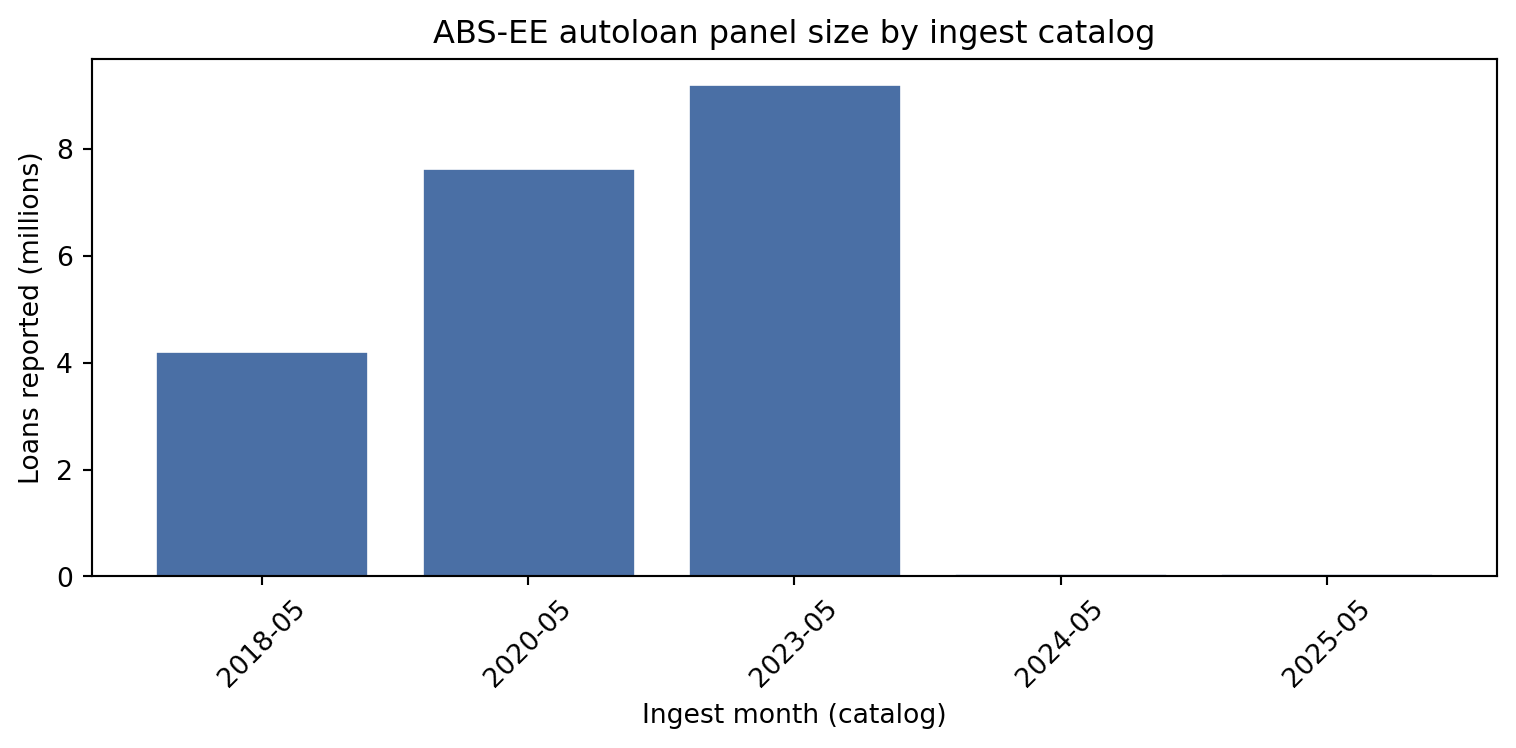

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(coverage["label"], coverage["loans"] / 1e6, color="#4A6FA5", edgecolor="white")
ax.set_ylabel("Loans reported (millions)")
ax.set_xlabel("Ingest month (catalog)")
ax.set_title("ABS-EE autoloan panel size by ingest catalog")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

## Loan-level snapshot — May 2018

For a loan-level cut, the notebook downloads a handful of trust Parquet files referenced in the **201805** catalog (single-file trusts only, to keep render time reasonable), then aggregates FICO and delinquency in DuckDB.

In [4]:
REPORTING_MONTH = "201805"
MAX_LOAN_FILES = 6

cat = fetch_catalog(REPORTING_MONTH)
if cat is None or cat.empty:
    raise RuntimeError(f"Catalog {REPORTING_MONTH} unavailable.")

pick = (
    cat.loc[~cat["r2_keys"].str.contains("|", regex=False)]
    .sort_values("loan_count", ascending=False)
    .head(MAX_LOAN_FILES)
)

loan_paths = []
for key in pick["r2_keys"]:
    dest = CACHE / Path(key).name
    fetch_r2(key, dest)
    loan_paths.append(str(dest))

paths_sql = "[" + ", ".join(f"'{p}'" for p in loan_paths) + "]"
con = duckdb.connect()

summary = con.execute(
    f"""
    SELECT
      COUNT(*) AS loans,
      ROUND(AVG(TRY_CAST(obligorCreditScore AS DOUBLE)), 1) AS avg_fico,
      ROUND(AVG(originalLoanAmount), 0) AS avg_orig_amount
    FROM read_parquet({paths_sql}, union_by_name=true)
    WHERE TRY_CAST(obligorCreditScore AS DOUBLE) BETWEEN 300 AND 850
    """
).fetchdf()

pick[["trust_name", "loan_count"]].rename(columns={"loan_count": "catalog_loans"})

,trust_name,catalog_loans
8,Nissan Auto Receivables 2018-A Owner Trust,48169
43,CarMax Auto Owner Trust 2017-2,47574
2,World Omni Auto Receivables Trust 2018-A,46720
47,Ford Credit Auto Owner Trust 2017-B,46043
57,GM Financial Consumer Automobile Receivables T...,43832
63,GM Financial Consumer Automobile Receivables T...,42215


In [5]:
summary

,loans,avg_fico,avg_orig_amount
0,254730,767.0,28006.0


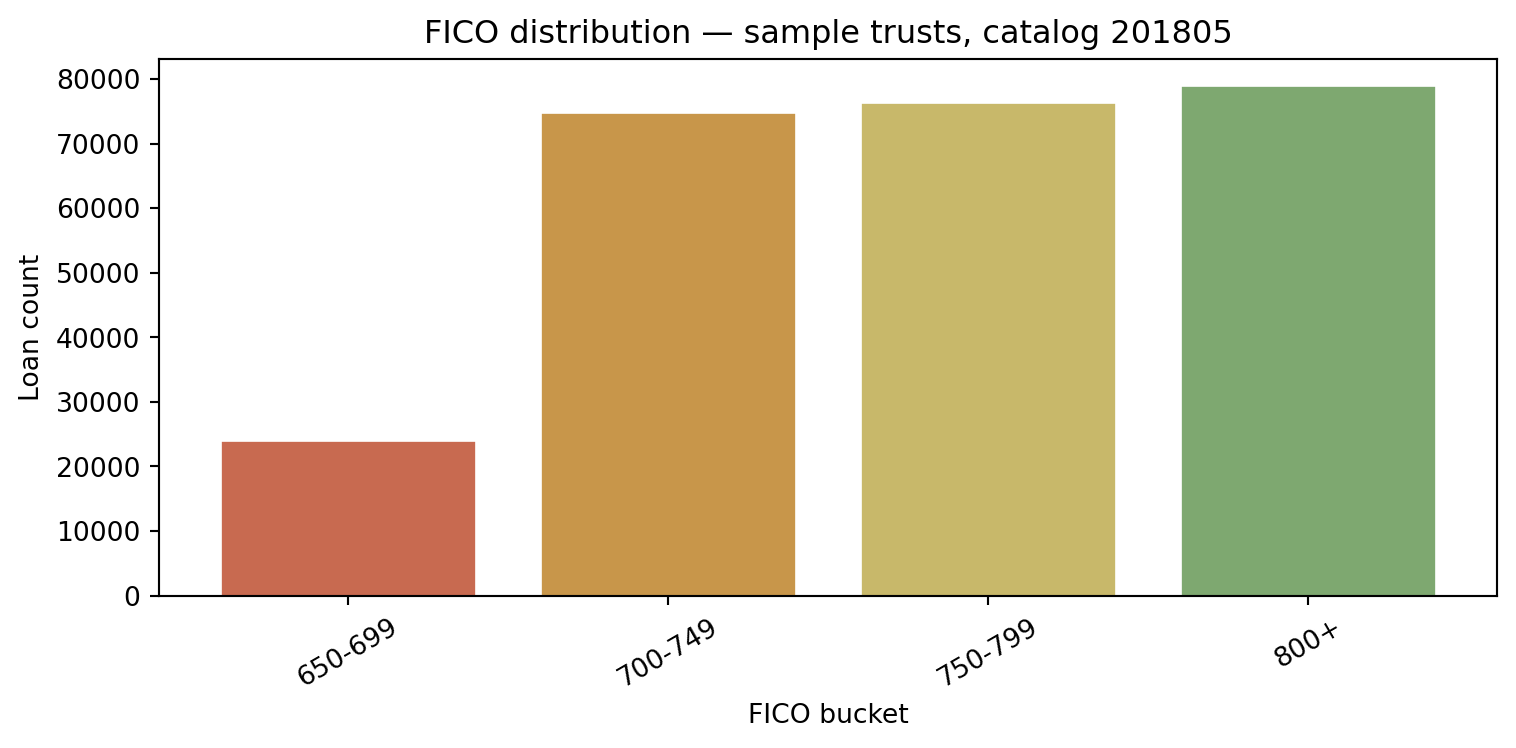

In [6]:
fico = con.execute(
    f"""
    SELECT
      CASE
        WHEN f < 600 THEN 'Sub-600'
        WHEN f < 650 THEN '600-649'
        WHEN f < 700 THEN '650-699'
        WHEN f < 750 THEN '700-749'
        WHEN f < 800 THEN '750-799'
        ELSE '800+'
      END AS bucket,
      COUNT(*) AS n
    FROM (
      SELECT TRY_CAST(obligorCreditScore AS DOUBLE) AS f
      FROM read_parquet({paths_sql}, union_by_name=true)
    ) t
    WHERE f BETWEEN 300 AND 850
    GROUP BY 1
    ORDER BY MIN(f)
    """
).fetchdf()

colors = ["#C86A50", "#C8964A", "#C8B86A", "#7EA870", "#5A8A8A", "#4A6FA5"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(fico["bucket"], fico["n"], color=colors[: len(fico)], edgecolor="white")
ax.set_ylabel("Loan count")
ax.set_xlabel("FICO bucket")
ax.set_title(f"FICO distribution — sample trusts, catalog {REPORTING_MONTH}")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

In [7]:
delinq = con.execute(
    f"""
    SELECT
      CASE
        WHEN LOWER(CAST(currentDelinquencyStatus AS VARCHAR)) IN ('current', '0') THEN 'Current'
        WHEN TRY_CAST(currentDelinquencyStatus AS INTEGER) = 1 THEN '1 period'
        WHEN TRY_CAST(currentDelinquencyStatus AS INTEGER) = 2 THEN '2 periods'
        WHEN TRY_CAST(currentDelinquencyStatus AS INTEGER) = 3 THEN '3 periods'
        ELSE '4+ / other'
      END AS bucket,
      COUNT(*) AS n
    FROM read_parquet({paths_sql}, union_by_name=true)
    WHERE currentDelinquencyStatus IS NOT NULL
    GROUP BY 1
    ORDER BY n DESC
    """
).fetchdf()

delinq["pct"] = (delinq["n"] / delinq["n"].sum() * 100).round(1)
delinq

,bucket,n,pct
0,Current,287934,99.7
1,4+ / other,996,0.3


## What this demonstrates

1. **Draft in Jupyter** — cell-by-cell analysis with real lake data.
2. **Render with Quarto** — `quarto render posts/2026-06-05-abs-ee-from-the-lake/index.ipynb` executes Python and bakes outputs into HTML.
3. **Deploy** — Cloudflare Pages runs the same render; set `R2_BASE_URL` in the build environment.

For interactive browser queries (no Python at build time), see the [live ABS-EE dashboard](../../dashboards/abs-ee.qmd). For a curated static snapshot of May 2018, see the [May 2018 showcase](../../dashboards/abs-ee-may2018.qmd).